In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import random
import matplotlib.pyplot as plt

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2512/2209252936.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


In [2]:
shots = 1024

qc = QuantumCircuit(1, 1)

qc.h(0)

qc.measure(0, 0)

print(qc.draw())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


In [3]:
simulator = AerSimulator()

job = simulator.run(qc, shots=shots)

result = job.result()

quantum_counts = result.get_counts()

print("Quantum Random Number Counts")
print(quantum_counts)

Quantum Random Number Counts
{'1': 488, '0': 536}


In [4]:
python_bits = [random.randint(0, 1) for _ in range(shots)]

python_counts = {
    '0': python_bits.count(0),
    '1': python_bits.count(1)
}

print("Python Random Number Counts")
print(python_counts)

Python Random Number Counts
{'0': 511, '1': 513}


In [5]:
quantum_prob = {
    '0': quantum_counts.get('0', 0) / shots,
    '1': quantum_counts.get('1', 0) / shots
}

python_prob = {
    '0': python_counts['0'] / shots,
    '1': python_counts['1'] / shots
}

print("Quantum Probabilities")
print(quantum_prob)

print()

print("Python Probabilities")
print(python_prob)

Quantum Probabilities
{'0': 0.5234375, '1': 0.4765625}

Python Probabilities
{'0': 0.4990234375, '1': 0.5009765625}


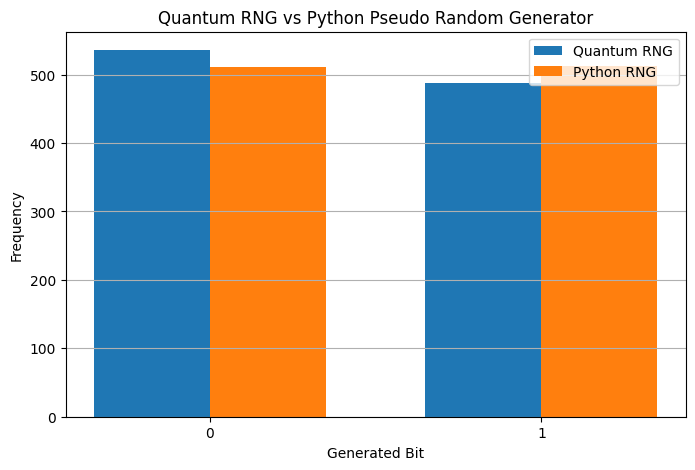

In [6]:
states = ['0', '1']

quantum_values = [quantum_counts.get(s, 0) for s in states]

python_values = [python_counts[s] for s in states]

x = range(len(states))

width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    [i-width/2 for i in x],
    quantum_values,
    width,
    label="Quantum RNG"
)

plt.bar(
    [i+width/2 for i in x],
    python_values,
    width,
    label="Python RNG"
)

plt.xticks(x, states)

plt.xlabel("Generated Bit")

plt.ylabel("Frequency")

plt.title("Quantum RNG vs Python Pseudo Random Generator")

plt.legend()

plt.grid(axis='y')

plt.show()

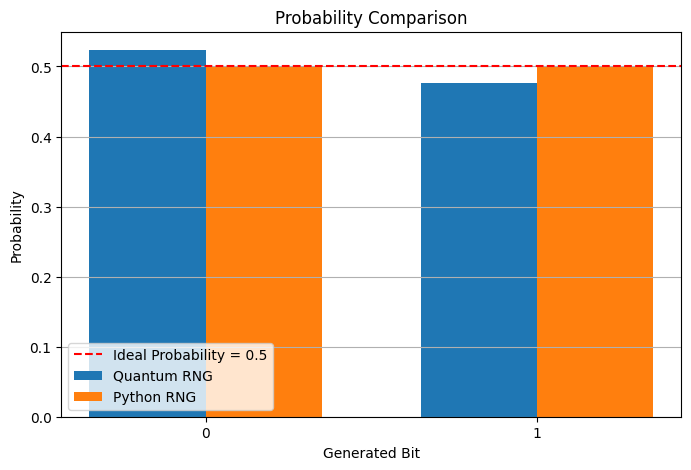

In [7]:
quantum_probability = [quantum_prob[s] for s in states]

python_probability = [python_prob[s] for s in states]

plt.figure(figsize=(8,5))

plt.bar(
    [i-width/2 for i in x],
    quantum_probability,
    width,
    label="Quantum RNG"
)

plt.bar(
    [i+width/2 for i in x],
    python_probability,
    width,
    label="Python RNG"
)

plt.axhline(
    y=0.5,
    color='red',
    linestyle='--',
    label="Ideal Probability = 0.5"
)

plt.xticks(x, states)

plt.xlabel("Generated Bit")

plt.ylabel("Probability")

plt.title("Probability Comparison")

plt.legend()

plt.grid(axis='y')

plt.show()

In [8]:
ideal_probability = 0.5

quantum_deviation = abs(quantum_prob['0'] - ideal_probability)

python_deviation = abs(python_prob['0'] - ideal_probability)

print("Statistical Analysis")

print()

print("Ideal Probability :", ideal_probability)

print("Quantum RNG Deviation :", round(quantum_deviation,4))

print("Python RNG Deviation :", round(python_deviation,4))

if quantum_deviation < python_deviation:
    print("\nQuantum RNG is closer to the ideal probability.")
elif python_deviation < quantum_deviation:
    print("\nPython RNG is closer to the ideal probability.")
else:
    print("\nBoth generators show similar statistical randomness.")

Statistical Analysis

Ideal Probability : 0.5
Quantum RNG Deviation : 0.0234
Python RNG Deviation : 0.001

Python RNG is closer to the ideal probability.


In [9]:
print("Comparison Table\n")

print(f"{'Generator':<20}{'P(0)':<10}{'P(1)':<10}{'Deviation'}")

print("-"*55)

print(f"{'Quantum RNG':<20}{quantum_prob['0']:<10.4f}{quantum_prob['1']:<10.4f}{quantum_deviation:.4f}")

print(f"{'Python RNG':<20}{python_prob['0']:<10.4f}{python_prob['1']:<10.4f}{python_deviation:.4f}")

Comparison Table

Generator           P(0)      P(1)      Deviation
-------------------------------------------------------
Quantum RNG         0.5234    0.4766    0.0234
Python RNG          0.4990    0.5010    0.0010


In [10]:
quantum_bits = []

for state, count in quantum_counts.items():
    quantum_bits.extend([state] * count)

random.shuffle(quantum_bits)

print("First 20 Quantum Random Bits")

print(quantum_bits[:20])

print()

print("First 20 Python Random Bits")

print(python_bits[:20])

First 20 Quantum Random Bits
['1', '1', '1', '0', '1', '0', '1', '1', '0', '1', '1', '0', '1', '0', '1', '1', '1', '0', '0', '1']

First 20 Python Random Bits
[0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0]


In [11]:
print("Conclusion\n")

print("The Hadamard gate places the qubit in an equal superposition of |0⟩ and |1⟩.")

print()

print("Measuring the qubit produces approximately equal probabilities of 0 and 1, simulating a quantum random number generator.")

print()

print("Python's random module also produces an approximately uniform distribution but is algorithmically generated (pseudo-random).")

print()

print("The frequency graphs, probability graphs, deviation values, and comparison table demonstrate that both generators produce nearly uniform distributions, while the quantum generator models randomness arising from quantum measurement.")

Conclusion

The Hadamard gate places the qubit in an equal superposition of |0⟩ and |1⟩.

Measuring the qubit produces approximately equal probabilities of 0 and 1, simulating a quantum random number generator.

Python's random module also produces an approximately uniform distribution but is algorithmically generated (pseudo-random).

The frequency graphs, probability graphs, deviation values, and comparison table demonstrate that both generators produce nearly uniform distributions, while the quantum generator models randomness arising from quantum measurement.
